# Exemplo2 : Classificação (Previsão de Espécies de Flores ) 

# Dados


In [39]:
from sklearn.datasets import load_iris
dados = load_iris()


In [40]:
# Atributos
X = dados.data # caracteristicas (tamanho da petúla, setúla  etc...)

# Alvo
y = dados.target

In [41]:
# caracteristicas
dados.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [42]:
# Classes 
dados.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [43]:
# Tabela  ( DataFrame)
import pandas as pd



df = pd.DataFrame(dados.data, columns=dados.feature_names)
df['target'] = y
df['target_name'] = df['target'].apply(lambda x: dados.target_names[x])
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [44]:
df['target_name'].value_counts()

target_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

# Divisão trieno/teste

In [45]:
from sklearn.model_selection import train_test_split
# 70% treino / 30% teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelo

In [68]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

In [47]:
# Modelo
modelo = DecisionTreeClassifier()

#treinamento
modelo.fit(X_treino, y_treino)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

# Previsão com os dados de teste


In [49]:
previsoes = modelo.predict(X_teste)
previsoes

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0,
       0])

In [52]:
# Tabela de comparação 
df_comp = pd.DataFrame(X_teste, columns=dados.feature_names)
df_comp['target'] = y_teste
df_comp['previsao'] = previsoes
df_comp

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,previsao
0,6.1,2.8,4.7,1.2,1,1
1,5.7,3.8,1.7,0.3,0,0
2,7.7,2.6,6.9,2.3,2,2
3,6.0,2.9,4.5,1.5,1,1
4,6.8,2.8,4.8,1.4,1,1
5,5.4,3.4,1.5,0.4,0,0
6,5.6,2.9,3.6,1.3,1,1
7,6.9,3.1,5.1,2.3,2,2
8,6.2,2.2,4.5,1.5,1,1
9,5.8,2.7,3.9,1.2,1,1


# Avaliação

In [64]:
from sklearn.metrics import accuracy_score

In [65]:
acuracia = accuracy_score(y_teste, previsoes)
print(f'O modelo acertou {acuracia * 100:.2f}% das previsões. ')

O modelo acertou 100.00% das previsões. 


# Plot da árvore

In [66]:
import matplotlib.pyplot as plt

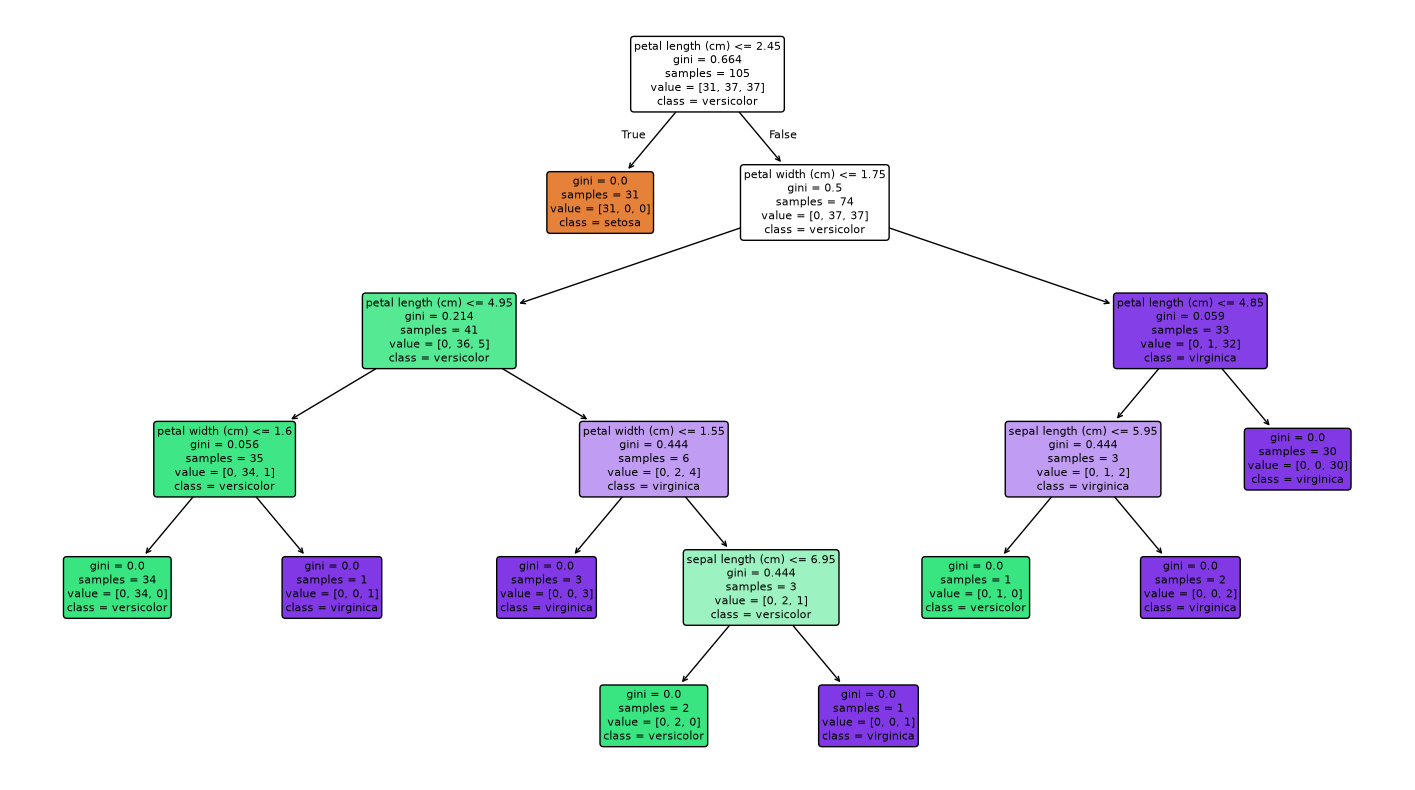

In [69]:
plt.figure(figsize=(18,10))
plot_tree(modelo,
          feature_names=dados.feature_names,
          class_names=dados.target_names,
          filled=True,
          rounded=True,
          fontsize=8)

plt.show()